# Mohd Zaid Oral Cancer Dataset — Preprocessing

**Source:** https://www.kaggle.com/datasets/zaidpy/oral-cancer-dataset
No published paper/protocol. Labels treated as unverified uploader claims.

## Core Findings
- **Provenance:** actual split is 500 CANCER / 250 NON CANCER (750), not the
  500/450 the listing describes. A duplicate "2.0" copy of the folder exists
  in the input dir; `ROOT` excludes it.
- **Duplicates:** 21 exact-dup groups (46 files) + 39 near-dup groups (88
  images, perceptual hash). 1 cross-class conflict (`001.jpeg`/`014.jpeg`)
  removed. Near-dups share a `case_group_id` used as `patient_id` to prevent
  split leakage.
- **Resolution outliers:** 7 images <100px side, flagged not dropped. Keep in
  training, exclude from val/test.
- **Label spot-check:** NON CANCER sample-verified as genuinely healthy (no
  lesion/OPMD). CANCER labels still unverified.
- **Metadata shortcut risk:** non-clinical features alone predict class at
  71–73% CV vs. 66.0% baseline. Two drivers: color mode/true format (40% of
  NON CANCER are PNG/WEBP relabeled `.jpeg` vs. 8.2% of CANCER) and EXIF
  presence (60.5% CANCER vs. 23.6% NON CANCER). `width` also nontrivial,
  recheck after resizing. Fix deferred to Notebook 3 (shared EXIF strip +
  RGB re-encode across all 3 datasets, then rerun this check).

## Final Class Distribution
| Condition | Count |
|---|---|
| 04. Oral Cancer | 478 |
| 01. Normal | 246 |
| **Total** | **724** |

In [1]:
#Step 1 — Imports and setup
!pip install imagehash --quiet

import hashlib
import re
from pathlib import Path
from PIL import Image
from PIL.ExifTags import TAGS
import imagehash
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('/kaggle/input/datasets/zaidpy/oral-cancer-dataset/Oral Cancer/Oral Cancer Dataset')
IMG_EXTS = {'.jpg', '.jpeg', '.png'}

In [2]:
#Step 2 — Explore folder structure and list all files

files = [p for p in sorted(ROOT.rglob('*')) if p.is_file() and p.suffix.lower() in IMG_EXTS]
print(f"Total image files found: {len(files)}")
for p in files[:10]:
    print(p)

Total image files found: 750
/kaggle/input/datasets/zaidpy/oral-cancer-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/001.jpeg
/kaggle/input/datasets/zaidpy/oral-cancer-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/002.jpeg
/kaggle/input/datasets/zaidpy/oral-cancer-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/003.jpeg
/kaggle/input/datasets/zaidpy/oral-cancer-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/004.jpeg
/kaggle/input/datasets/zaidpy/oral-cancer-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/005.jpeg
/kaggle/input/datasets/zaidpy/oral-cancer-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/006.jpeg
/kaggle/input/datasets/zaidpy/oral-cancer-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/007.jpeg
/kaggle/input/datasets/zaidpy/oral-cancer-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/008.jpeg
/kaggle/input/datasets/zaidpy/oral-cancer-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/009.jpeg
/kaggle/input/datasets/zaidpy/oral-cancer-dataset/Oral Cancer/Oral Cancer Dataset/CANCER/

In [3]:
#Step 3 — Compute file hashes, perceptual hashes, and basic file metadata
# Added: phash (for near-duplicate detection in Step 4b), file size and
# color mode (used later in the Step 8c shortcut check).

records = []
for p in files:
    label_folder = p.parent.name  # 'CANCER' or 'NON CANCER'
    with open(p, 'rb') as f:
        md5 = hashlib.md5(f.read()).hexdigest()

    with Image.open(p) as im:
        phash = imagehash.phash(im)   # perceptual hash -> catches near-duplicates MD5 misses
        color_mode = im.mode          # e.g. 'RGB', 'L', 'CMYK', 'P'

    records.append({
        'label_folder': label_folder, 'file_name': p.name, 'file_path': str(p),
        'md5': md5, 'phash': phash,
        'file_size_bytes': p.stat().st_size, 'color_mode': color_mode,
    })

raw_df = pd.DataFrame(records)
print(raw_df['label_folder'].value_counts())

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


label_folder
CANCER        500
NON CANCER    250
Name: count, dtype: int64


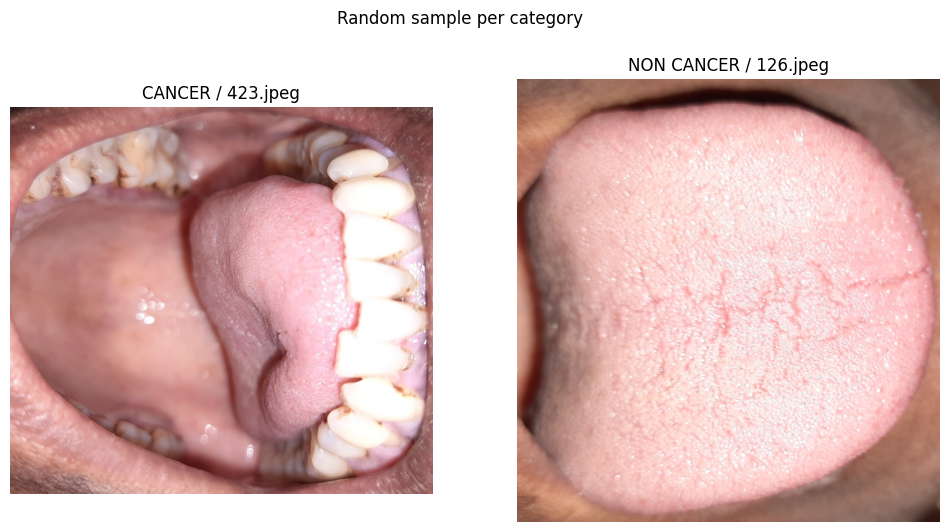

In [4]:
#Step 3-visual — Quick sanity check: one random image per category

categories = raw_df['label_folder'].unique()
fig, axes = plt.subplots(1, len(categories), figsize=(6 * len(categories), 6))
if len(categories) == 1:
    axes = [axes]
for ax, cat in zip(axes, categories):
    sample_row = raw_df[raw_df['label_folder'] == cat].sample(1).iloc[0]
    ax.imshow(Image.open(sample_row['file_path']))
    ax.set_title(f"{cat} / {sample_row['file_name']}")
    ax.axis('off')
plt.suptitle("Random sample per category")
plt.show()

In [5]:
#Step 3c — Format and color-mode breakdown by class
# Extension and color mode are acquisition fingerprints Step 8c's shortcut
# check doesn't show directly. Worth seeing the raw distribution.

raw_df['extension'] = raw_df['file_name'].apply(lambda x: Path(x).suffix.lower())

print("File extension by class:")
print(raw_df.groupby('label_folder')['extension'].value_counts())
print()
print("Color mode by class:")
print(raw_df.groupby('label_folder')['color_mode'].value_counts())

File extension by class:
label_folder  extension
CANCER        .jpeg        500
NON CANCER    .jpeg        250
Name: count, dtype: int64

Color mode by class:
label_folder  color_mode
CANCER        RGB           484
              RGBA           12
              P               4
NON CANCER    RGB           163
              RGBA           87
Name: count, dtype: int64


In [6]:
#Step 3d — Check whether the .jpeg extension matches the actual file format
# JPEG doesn't support an alpha channel, so an RGBA image with a .jpeg
# extension likely means the file is actually a PNG (or other format)
# renamed rather than converted. PIL reads the true format from the file
# header, not the filename.

def get_true_format(path):
    try:
        with Image.open(path) as im:
            return im.format
    except Exception:
        return 'UNREADABLE'

raw_df['true_format'] = raw_df['file_path'].apply(get_true_format)

print("True format (from file header) vs class:")
print(raw_df.groupby('label_folder')['true_format'].value_counts())
print()

mismatches = raw_df[raw_df['true_format'] != 'JPEG']
print(f"Files with .jpeg extension but non-JPEG actual format: {len(mismatches)}")
if len(mismatches) > 0:
    print(mismatches.groupby('label_folder')['true_format'].value_counts())

True format (from file header) vs class:
label_folder  true_format
CANCER        JPEG           459
              WEBP            21
              PNG             20
NON CANCER    JPEG           150
              PNG             89
              WEBP            11
Name: count, dtype: int64

Files with .jpeg extension but non-JPEG actual format: 141
label_folder  true_format
CANCER        WEBP           21
              PNG            20
NON CANCER    PNG            89
              WEBP           11
Name: count, dtype: int64


In [7]:
#Step 4 — Detect exact duplicate images

dupes = raw_df[raw_df.duplicated('md5', keep=False)]
print(f"Duplicate groups: {dupes['md5'].nunique()} | Files involved: {len(dupes)}")

Duplicate groups: 21 | Files involved: 46


In [8]:
#Step 4b — Detect near-duplicate images via perceptual hashing
# MD5 only catches byte-identical files. A re-saved, resized, or lightly
# cropped copy of the same photo passes MD5 but is still the same underlying
# image — and if such a pair later ends up split across train/test, that's
# leakage. We cluster images whose perceptual hashes are within a small
# Hamming distance of each other.

HAMMING_THRESHOLD = 8  # out of 64 bits; eyeball a few groups below and adjust if needed

n = len(raw_df)
parent = list(range(n))

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(x, y):
    rx, ry = find(x), find(y)
    if rx != ry:
        parent[rx] = ry

phashes = raw_df['phash'].tolist()
for i in range(n):
    for j in range(i + 1, n):
        if phashes[i] - phashes[j] <= HAMMING_THRESHOLD:
            union(i, j)

raw_df['case_group_id'] = [find(i) for i in range(n)]

group_sizes = raw_df.groupby('case_group_id').size()
multi_image_groups = group_sizes[group_sizes > 1]
print(f"Near-duplicate groups (size > 1): {len(multi_image_groups)}")
print(f"Images involved in a near-duplicate group: {multi_image_groups.sum()}")

# A group spanning more than one label is worse than a plain duplicate — it
# means visually near-identical images were filed under different diagnoses.
group_label_counts = raw_df.groupby('case_group_id')['label_folder'].nunique()
near_dup_cross_class_groups = group_label_counts[group_label_counts > 1].index
print(f"Near-duplicate groups spanning CANCER *and* NON CANCER: {len(near_dup_cross_class_groups)}")
raw_df[raw_df['case_group_id'].isin(near_dup_cross_class_groups)][
    ['label_folder', 'file_name', 'case_group_id']
].sort_values('case_group_id')

Near-duplicate groups (size > 1): 39
Images involved in a near-duplicate group: 88
Near-duplicate groups spanning CANCER *and* NON CANCER: 1


,label_folder,file_name,case_group_id
0,CANCER,001.jpeg,513
513,NON CANCER,014.jpeg,513


In [9]:
#Step 5 — Detect cross-class conflicts (exact-hash AND near-duplicate based)

hash_to_labels = raw_df.groupby('md5')['label_folder'].nunique()
cross_class_hashes = hash_to_labels[hash_to_labels > 1].index

cross_class = raw_df[
    raw_df['md5'].isin(cross_class_hashes) | raw_df['case_group_id'].isin(near_dup_cross_class_groups)
].sort_values('md5')

print(f"Exact-hash cross-class conflicts: {len(cross_class_hashes)}")
print(f"Near-duplicate cross-class conflicts: {len(near_dup_cross_class_groups)}")
cross_class[['label_folder', 'file_name', 'md5', 'case_group_id']]

Exact-hash cross-class conflicts: 1
Near-duplicate cross-class conflicts: 1


,label_folder,file_name,md5,case_group_id
0,CANCER,001.jpeg,00b5c56942f93a4b429141aceb71698b,513
513,NON CANCER,014.jpeg,00b5c56942f93a4b429141aceb71698b,513


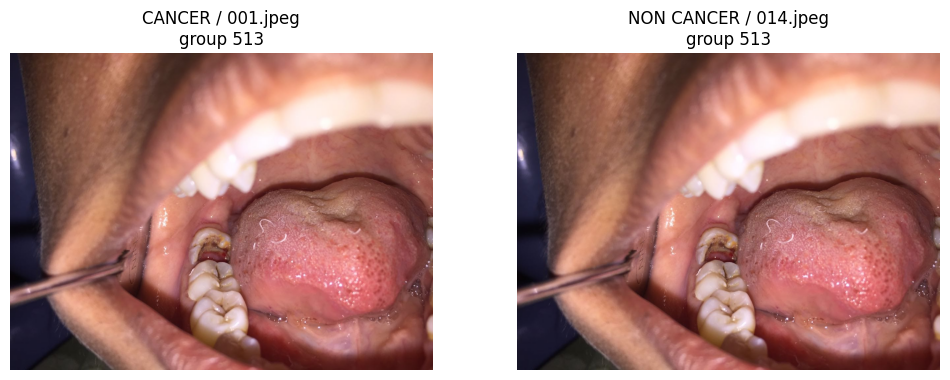

In [10]:
#Step 6 — Visually verify cross-class conflicts
fig, axes = plt.subplots(1, len(cross_class), figsize=(6 * len(cross_class), 6))
if len(cross_class) == 1:
    axes = [axes]
for ax, (_, row) in zip(axes, cross_class.iterrows()):
    ax.imshow(Image.open(row['file_path']))
    ax.set_title(f"{row['label_folder']} / {row['file_name']}\ngroup {row['case_group_id']}")
    ax.axis('off')
plt.show()

In [11]:
#Step 7 — Remove conflicting images and deduplicate

raw_df = raw_df[
    ~raw_df['md5'].isin(cross_class_hashes) &
    ~raw_df['case_group_id'].isin(near_dup_cross_class_groups)
]  # drop confirmed 001/014 conflict + any near-duplicate cross-class conflicts

clean_df = raw_df.drop_duplicates(subset='md5', keep='first').reset_index(drop=True)

print(f"Final unique, non-conflicting images: {len(clean_df)}")
print(clean_df['label_folder'].value_counts())

Final unique, non-conflicting images: 724
label_folder
CANCER        478
NON CANCER    246
Name: count, dtype: int64


In [12]:
#Step 8 — Validate images, extract dimensions, and flag resolution outliers

MIN_SIDE_PX = 100            # below this, upsampling to 224x224 for ViT loses too much real detail
EXTREME_ASPECT_RATIO = 3.0   # beyond this looks like a crop/screenshot, not a clinical photo

widths, heights, valid_flags = [], [], []
for _, row in clean_df.iterrows():
    p = Path(row['file_path'])
    try:
        with Image.open(p) as im:
            w, h = im.size
        valid = True
    except Exception as e:
        w, h = None, None
        valid = False
        print(f"Could not open {p}: {e}")
    widths.append(w)
    heights.append(h)
    valid_flags.append(valid)

clean_df['width'] = widths
clean_df['height'] = heights
clean_df['is_valid_image'] = valid_flags
clean_df['aspect_ratio'] = clean_df['width'] / clean_df['height']

clean_df['is_resolution_outlier'] = (
    (clean_df['width'] < MIN_SIDE_PX) | (clean_df['height'] < MIN_SIDE_PX) |
    (clean_df['aspect_ratio'] > EXTREME_ASPECT_RATIO) | (clean_df['aspect_ratio'] < 1 / EXTREME_ASPECT_RATIO)
)

print(f"Images failing to open: {(~clean_df['is_valid_image']).sum()}")
print(f"Resolution outliers (too small / unusual aspect ratio): {clean_df['is_resolution_outlier'].sum()}")
clean_df.loc[clean_df['is_resolution_outlier'], ['file_name', 'label_folder', 'width', 'height', 'aspect_ratio']]

Images failing to open: 0
Resolution outliers (too small / unusual aspect ratio): 7


,file_name,label_folder,width,height,aspect_ratio
174,190.jpeg,CANCER,93,97,0.958763
338,354.jpeg,CANCER,206,96,2.145833
516,040.jpeg,NON CANCER,154,98,1.571429
530,054.jpeg,NON CANCER,99,122,0.811475
546,070.jpeg,NON CANCER,90,116,0.775862
554,078.jpeg,NON CANCER,155,89,1.741573
561,085.jpeg,NON CANCER,95,121,0.785124


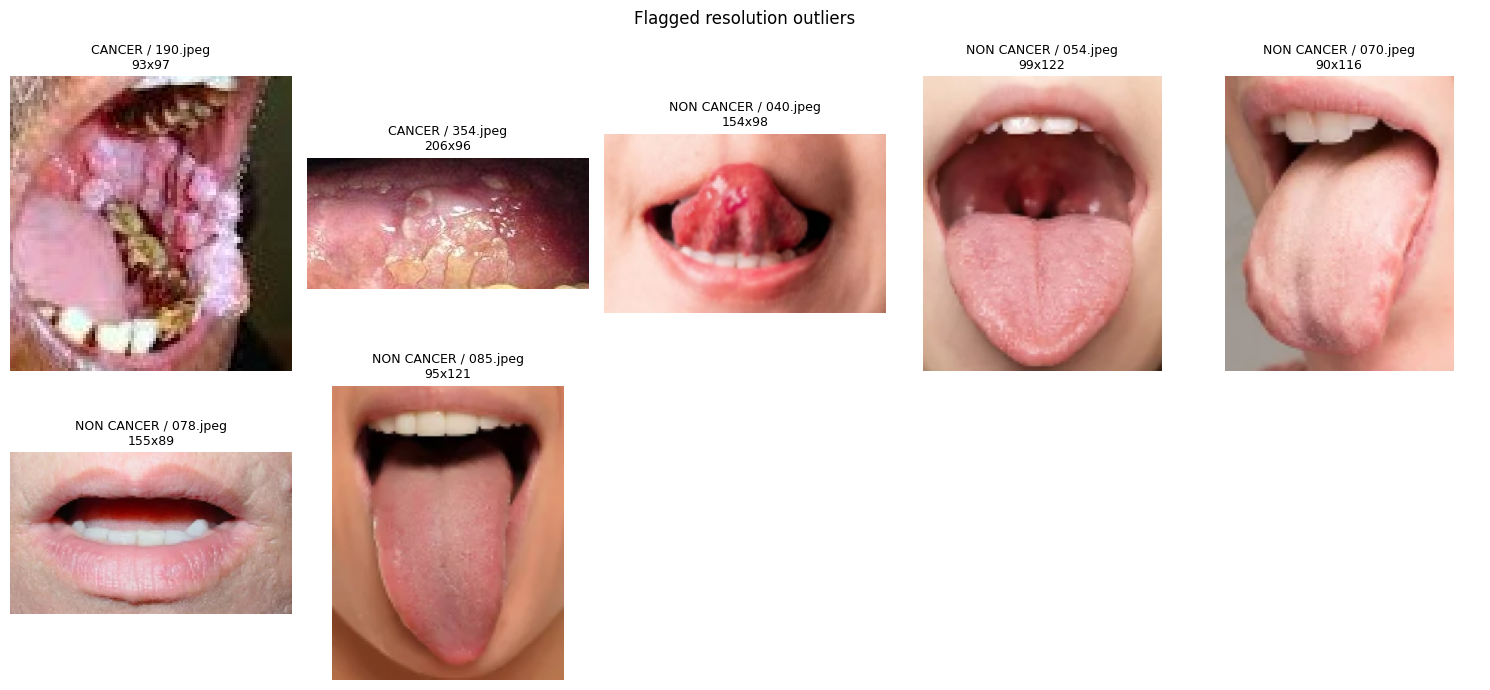

In [13]:
#Step 8-visual — Display flagged resolution outliers

outliers_df = clean_df[clean_df['is_resolution_outlier']].reset_index(drop=True)
n = len(outliers_df)

if n == 0:
    print("No resolution outliers to display.")
else:
    cols = min(n, 5)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3.5 * rows))
    axes = axes.flatten() if n > 1 else [axes]
    for i, (_, row) in enumerate(outliers_df.iterrows()):
        axes[i].imshow(Image.open(row['file_path']))
        axes[i].set_title(f"{row['label_folder']} / {row['file_name']}\n{row['width']}x{row['height']}", fontsize=9)
        axes[i].axis('off')
    for j in range(n, len(axes)):
        axes[j].axis('off')
    plt.suptitle("Flagged resolution outliers")
    plt.tight_layout()
    plt.show()

In [14]:
#Step 8b — Extract EXIF metadata and check acquisition consistency per class
# If CANCER and NON CANCER images were captured with systematically different
# cameras/apps, that's a shortcut a model could exploit instead of learning
# the lesion itself. Most scraped medical images have no EXIF at all — that's
# expected — but any pattern that does exist is worth knowing about.

def read_exif_tags(path):
    try:
        with Image.open(path) as im:
            exif_raw = im.getexif()
        if not exif_raw:
            return {'camera_make': None, 'camera_model': None, 'camera_software': None}
        tags = {TAGS.get(k, k): v for k, v in exif_raw.items()}
        return {'camera_make': tags.get('Make'), 'camera_model': tags.get('Model'),
                'camera_software': tags.get('Software')}
    except Exception:
        return {'camera_make': None, 'camera_model': None, 'camera_software': None}

exif_records = clean_df['file_path'].apply(read_exif_tags).apply(pd.Series)
clean_df = pd.concat([clean_df, exif_records], axis=1)

has_exif = clean_df[['camera_make', 'camera_model', 'camera_software']].notna().any(axis=1)
print(f"Images with any EXIF camera/software tag: {has_exif.sum()} / {len(clean_df)}")
if has_exif.any():
    print(clean_df.loc[has_exif].groupby('label_folder')[
        ['camera_make', 'camera_model', 'camera_software']
    ].agg(lambda s: s.dropna().unique().tolist()))

Images with any EXIF camera/software tag: 347 / 724
                                                    camera_make  \
label_folder                                                      
CANCER        [NIKON CORPORATION, FUJIFILM, samsung, Motorol...   
NON CANCER                 [samsung, Xiaomi, NIKON CORPORATION]   

                                                   camera_model  \
label_folder                                                      
CANCER        [NIKON D80, FinePixS1Pro, SM-G360H, MotoG3, SM...   
NON CANCER           [SM-M307F, SM-M315F, M2101K6I, NIKON D810]   

                                                camera_software  
label_folder                                                     
CANCER        [Adobe Photoshop CC 2014 (Macintosh), Adobe Ph...  
NON CANCER    [M307FXXS2ATB3, M315FXXU2ATJ9, Windows Photo E...  


In [15]:
# Step 8b(ii) — Quantify editing-software prevalence by class
edit_keywords = ['photoshop', 'gimp', 'lightroom', 'picasa', 'snapseed']
clean_df['was_software_edited'] = clean_df['camera_software'].fillna('').str.lower().apply(
    lambda s: any(k in s for k in edit_keywords)
)
clean_df['has_exif'] = clean_df[['camera_make', 'camera_model', 'camera_software']].notna().any(axis=1)

print(clean_df.groupby('label_folder')['has_exif'].mean().rename('pct_with_exif'))
print(clean_df.groupby('label_folder')['was_software_edited'].sum().rename('n_software_edited'))

label_folder
CANCER        0.604603
NON CANCER    0.235772
Name: pct_with_exif, dtype: float64
label_folder
CANCER        18
NON CANCER     1
Name: n_software_edited, dtype: int64


In [16]:
#Step 8c — Shortcut check: can the label be guessed from non-clinical properties alone?

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

feature_df = clean_df[['width', 'height', 'aspect_ratio', 'file_size_bytes']].copy()
feature_df['color_mode_enc'] = LabelEncoder().fit_transform(clean_df['color_mode'])
feature_df['true_format_enc'] = LabelEncoder().fit_transform(clean_df['true_format'])
feature_df['has_exif'] = clean_df['has_exif'].astype(int)
feature_df['was_software_edited'] = clean_df['was_software_edited'].astype(int)

y = (clean_df['label_folder'] == 'CANCER').astype(int)
majority_baseline = y.value_counts(normalize=True).max()

scores = cross_val_score(LogisticRegression(max_iter=1000), feature_df, y, cv=5)
print(f"Majority-class baseline accuracy: {majority_baseline:.3f}")
print(f"5-fold CV accuracy using ONLY non-clinical metadata (now incl. true_format): {scores.mean():.3f} (+/- {scores.std():.3f})")
if scores.mean() > majority_baseline + 0.05:
    print("Class is partially predictable from file metadata alone - investigate before training.")
else:
    print("No strong metadata shortcut detected.")

Majority-class baseline accuracy: 0.660
5-fold CV accuracy using ONLY non-clinical metadata (now incl. true_format): 0.710 (+/- 0.113)
No strong metadata shortcut detected.


In [17]:
#Step 8c(ii) — Persist shortcut-check baseline for comparison after EXIF stripping
# Stripping happens later, in the combining notebook. Save these numbers now
# so Notebook 3 has a documented "before" baseline — if CV accuracy doesn't
# drop back toward the majority baseline after stripping, the shortcut
# wasn't actually closed.

import json

shortcut_baseline = {
    'source_dataset': 'oral_cancer_zaidpy',
    'majority_baseline_accuracy': float(majority_baseline),
    'metadata_only_cv_accuracy_mean': float(scores.mean()),
    'metadata_only_cv_accuracy_std': float(scores.std()),
    'features_used': list(feature_df.columns),
    'flagged_as_shortcut_risk': bool(scores.mean() > majority_baseline + 0.05),
}

with open('/kaggle/working/zaidpy_shortcut_baseline.json', 'w') as f:
    json.dump(shortcut_baseline, f, indent=2)

print(shortcut_baseline)

{'source_dataset': 'oral_cancer_zaidpy', 'majority_baseline_accuracy': 0.6602209944751382, 'metadata_only_cv_accuracy_mean': 0.7097413793103448, 'metadata_only_cv_accuracy_std': 0.11283939424763678, 'features_used': ['width', 'height', 'aspect_ratio', 'file_size_bytes', 'color_mode_enc', 'true_format_enc', 'has_exif', 'was_software_edited'], 'flagged_as_shortcut_risk': False}


In [18]:
#Step 8c(iii) — Which feature is actually carrying the signal?
# Aggregate CV accuracy alone doesn't say what's driving it. Fit once on
# all the data (not for evaluation, just to inspect direction/magnitude)
# and look at which coefficient is largest.

from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(feature_df)
clf = LogisticRegression(max_iter=1000).fit(X_scaled, y)

coef_df = pd.DataFrame({
    'feature': feature_df.columns,
    'coefficient': clf.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df)

               feature  coefficient
4       color_mode_enc    -1.044939
6             has_exif     0.807549
0                width    -0.563591
2         aspect_ratio     0.311084
1               height    -0.216208
3      file_size_bytes     0.195337
7  was_software_edited     0.122512
5      true_format_enc     0.041933


In [19]:
#Step 8c(iv) — Append this run to the saved baseline
shortcut_baseline_v2 = {
    'source_dataset': 'oral_cancer_zaidpy',
    'run': 'with_true_format_feature',
    'majority_baseline_accuracy': float(majority_baseline),
    'metadata_only_cv_accuracy_mean': float(scores.mean()),
    'metadata_only_cv_accuracy_std': float(scores.std()),
    'features_used': list(feature_df.columns),
    'note': 'Result is within noise of the original 0.733 run (Step 8c v1); '
            'not evidence the shortcut is resolved. See true_format/color_mode '
            'collinearity. Real fix is EXIF strip + re-encode in Notebook 3, '
            'to be verified by rerunning this same check on normalized data.',
}

with open('/kaggle/working/zaidpy_shortcut_baseline_v2.json', 'w') as f:
    json.dump(shortcut_baseline_v2, f, indent=2)

print(shortcut_baseline_v2)

{'source_dataset': 'oral_cancer_zaidpy', 'run': 'with_true_format_feature', 'majority_baseline_accuracy': 0.6602209944751382, 'metadata_only_cv_accuracy_mean': 0.7097413793103448, 'metadata_only_cv_accuracy_std': 0.11283939424763678, 'features_used': ['width', 'height', 'aspect_ratio', 'file_size_bytes', 'color_mode_enc', 'true_format_enc', 'has_exif', 'was_software_edited'], 'note': 'Result is within noise of the original 0.733 run (Step 8c v1); not evidence the shortcut is resolved. See true_format/color_mode collinearity. Real fix is EXIF strip + re-encode in Notebook 3, to be verified by rerunning this same check on normalized data.'}


In [20]:
#Step 8c(v) — Record which features actually drove the shortcut
with open('/kaggle/working/zaidpy_shortcut_baseline_v2.json', 'r') as f:
    baseline_v2 = json.load(f)

baseline_v2['coefficient_analysis'] = {
    'top_driver': 'color_mode_enc (coef -1.04), reflects the PNG/WEBP-relabeled-as-JPEG issue',
    'second_driver': 'has_exif (coef +0.81), independent of color_mode, CANCER images 60.5% EXIF vs NON CANCER 23.6%',
    'true_format_enc': 'coef 0.042, effectively noise, collinear with color_mode',
    'width': 'coef -0.56, may partially survive pad-to-square resizing as a sharpness/detail artifact, recheck after Notebook 3 normalization',
}

with open('/kaggle/working/zaidpy_shortcut_baseline_v2.json', 'w') as f:
    json.dump(baseline_v2, f, indent=2)

/tmp/ipykernel_16/2510139623.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = clean_df.groupby('label_folder', group_keys=False).apply(


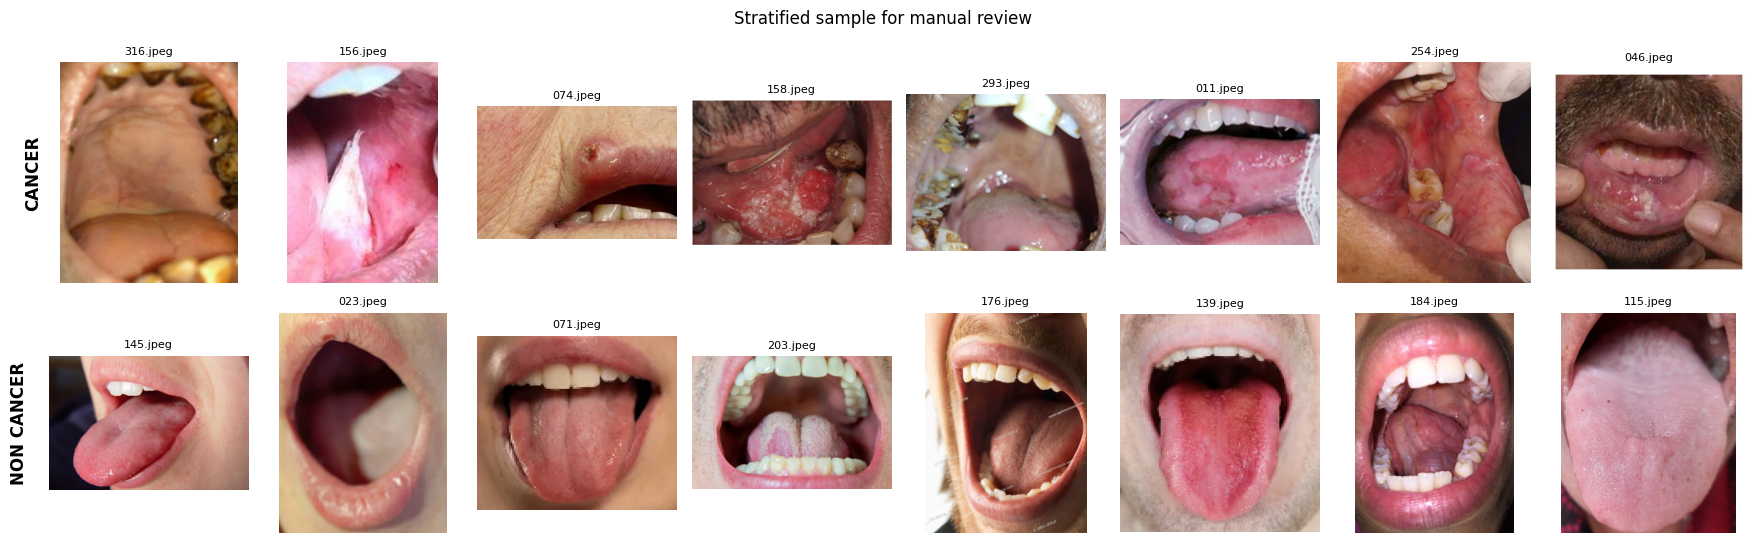

In [21]:
#Step 8d — Stratified visual audit (manual review sample)
SAMPLE_PER_CLASS = 8
sample_df = clean_df.groupby('label_folder', group_keys=False).apply(
    lambda d: d.sample(min(SAMPLE_PER_CLASS, len(d)))
)

fig, axes = plt.subplots(2, SAMPLE_PER_CLASS, figsize=(2.2 * SAMPLE_PER_CLASS, 5.5))
for row_idx, label in enumerate(['CANCER', 'NON CANCER']):
    subset = sample_df[sample_df['label_folder'] == label].reset_index(drop=True)
    for col_idx in range(SAMPLE_PER_CLASS):
        ax = axes[row_idx, col_idx]
        if col_idx < len(subset):
            row = subset.loc[col_idx]
            ax.imshow(Image.open(row['file_path']))
            ax.set_title(row['file_name'], fontsize=8)
        ax.axis('off')
    axes[row_idx, 0].text(-0.15, 0.5, label, fontsize=12, fontweight='bold',
                           rotation=90, va='center', ha='center',
                           transform=axes[row_idx, 0].transAxes)

plt.suptitle("Stratified sample for manual review")
plt.tight_layout()
plt.show()

In [22]:
#Step 9 — Map labels to clinical_condition (SMART-OM–style naming)

# CANCER      -> '04. Oral Cancer'  (still just the uploader's claim, not
#                clinically re-confirmed by this team)
# NON CANCER  -> '01. Normal'  (visually spot-checked via Step 8d: sampled
#                images showed healthy mucosa, no visible lesion, benign
#                finding, or OPMD presentation. This resolves the earlier
#                uncertainty about whether NON CANCER might include
#                non-cancerous lesions - it doesn't appear to.)
clean_df['clinical_condition'] = clean_df['label_folder'].map({
    'CANCER': '04. Oral Cancer', 'NON CANCER': '01. Normal'
})

# Confidence now differs by class: CANCER is still an unverified uploader
# claim, NON CANCER has been visually spot-checked and held up.
clean_df['label_confidence'] = clean_df['label_folder'].map({
    'CANCER': 'unverified_uploader_label',
    'NON CANCER': 'visually_spot_checked_healthy',
})

print(clean_df['clinical_condition'].value_counts())
print(clean_df['label_confidence'].value_counts())

clinical_condition
04. Oral Cancer    478
01. Normal         246
Name: count, dtype: int64
label_confidence
unverified_uploader_label        478
visually_spot_checked_healthy    246
Name: count, dtype: int64


In [23]:
#Step 10 — Assign patient/case IDs (synthetic — no real patient data available)
# Near-duplicate images (same case_group_id from Step 4b) get the SAME
# synthetic ID, so a later patient-level split won't separate two photos
# of the same lesion into different sides of train/test.

clean_df['image_stem'] = clean_df['file_name'].apply(lambda x: Path(x).stem)
clean_df['patient_id'] = clean_df['case_group_id'].apply(lambda g: f'ZAIDPY_CASE_{g}')

In [24]:
#Step 11 — Add placeholder annotation columns (this dataset has no annotations)

clean_df['annotation_stage'] = None
clean_df['oral_site'] = None
clean_df['capture_type'] = None
clean_df['annotation_count'] = 0
clean_df['total_annotated_points'] = 0

In [25]:
#Step 12 — Assemble standardized DataFrame (matching smart_om_standardized schema)

zaidpy_standardized_df = clean_df[[
    'file_name', 'file_path', 'image_stem', 'patient_id', 'clinical_condition',
    'label_confidence', 'annotation_stage', 'oral_site', 'capture_type',
    'width', 'height', 'aspect_ratio', 'is_valid_image', 'is_resolution_outlier',
    'color_mode', 'file_size_bytes', 'camera_make', 'camera_model', 'camera_software',
    'case_group_id', 'annotation_count', 'total_annotated_points'
]].copy()

zaidpy_standardized_df.insert(0, 'source_dataset', 'oral_cancer_zaidpy')
zaidpy_standardized_df.head()

,source_dataset,file_name,file_path,image_stem,patient_id,clinical_condition,label_confidence,annotation_stage,oral_site,capture_type,...,is_valid_image,is_resolution_outlier,color_mode,file_size_bytes,camera_make,camera_model,camera_software,case_group_id,annotation_count,total_annotated_points
0,oral_cancer_zaidpy,002.jpeg,/kaggle/input/datasets/zaidpy/oral-cancer-data...,002,ZAIDPY_CASE_1,04. Oral Cancer,unverified_uploader_label,None,None,None,...,True,False,RGB,26596,None,None,None,1,0,0
1,oral_cancer_zaidpy,003.jpeg,/kaggle/input/datasets/zaidpy/oral-cancer-data...,003,ZAIDPY_CASE_485,04. Oral Cancer,unverified_uploader_label,None,None,None,...,True,False,RGB,41912,None,None,None,485,0,0
2,oral_cancer_zaidpy,004.jpeg,/kaggle/input/datasets/zaidpy/oral-cancer-data...,004,ZAIDPY_CASE_3,04. Oral Cancer,unverified_uploader_label,None,None,None,...,True,False,RGB,43534,None,None,None,3,0,0
3,oral_cancer_zaidpy,005.jpeg,/kaggle/input/datasets/zaidpy/oral-cancer-data...,005,ZAIDPY_CASE_4,04. Oral Cancer,unverified_uploader_label,None,None,None,...,True,False,RGB,43301,None,None,None,4,0,0
4,oral_cancer_zaidpy,006.jpeg,/kaggle/input/datasets/zaidpy/oral-cancer-data...,006,ZAIDPY_CASE_5,04. Oral Cancer,unverified_uploader_label,None,None,None,...,True,False,RGB,133937,None,None,None,5,0,0


In [26]:
#Step 13 — Final sanity checks and export

assert zaidpy_standardized_df['file_path'].nunique() == len(zaidpy_standardized_df), "Duplicate file paths found"
assert zaidpy_standardized_df['clinical_condition'].isna().sum() == 0, "Unmatched clinical conditions"
assert zaidpy_standardized_df['patient_id'].isna().sum() == 0, "Unmatched patient IDs"
assert zaidpy_standardized_df['is_valid_image'].all(), "Corrupted images detected"

n_groups_multi = zaidpy_standardized_df.groupby('case_group_id').size().gt(1).sum()
n_outliers = zaidpy_standardized_df['is_resolution_outlier'].sum()

export_path = Path('/kaggle/working/zaidpy_standardized.csv')
zaidpy_standardized_df.to_csv(export_path, index=False)

print("All assertions passed successfully!")
print("Exported shape:", zaidpy_standardized_df.shape)
print(f"Case groups with >1 image (keep together in any split): {n_groups_multi}")
print(f"Resolution outliers flagged (review before training): {n_outliers}")
zaidpy_standardized_df.head(5)

All assertions passed successfully!
Exported shape: (724, 23)
Case groups with >1 image (keep together in any split): 20
Resolution outliers flagged (review before training): 7


,source_dataset,file_name,file_path,image_stem,patient_id,clinical_condition,label_confidence,annotation_stage,oral_site,capture_type,...,is_valid_image,is_resolution_outlier,color_mode,file_size_bytes,camera_make,camera_model,camera_software,case_group_id,annotation_count,total_annotated_points
0,oral_cancer_zaidpy,002.jpeg,/kaggle/input/datasets/zaidpy/oral-cancer-data...,002,ZAIDPY_CASE_1,04. Oral Cancer,unverified_uploader_label,None,None,None,...,True,False,RGB,26596,None,None,None,1,0,0
1,oral_cancer_zaidpy,003.jpeg,/kaggle/input/datasets/zaidpy/oral-cancer-data...,003,ZAIDPY_CASE_485,04. Oral Cancer,unverified_uploader_label,None,None,None,...,True,False,RGB,41912,None,None,None,485,0,0
2,oral_cancer_zaidpy,004.jpeg,/kaggle/input/datasets/zaidpy/oral-cancer-data...,004,ZAIDPY_CASE_3,04. Oral Cancer,unverified_uploader_label,None,None,None,...,True,False,RGB,43534,None,None,None,3,0,0
3,oral_cancer_zaidpy,005.jpeg,/kaggle/input/datasets/zaidpy/oral-cancer-data...,005,ZAIDPY_CASE_4,04. Oral Cancer,unverified_uploader_label,None,None,None,...,True,False,RGB,43301,None,None,None,4,0,0
4,oral_cancer_zaidpy,006.jpeg,/kaggle/input/datasets/zaidpy/oral-cancer-data...,006,ZAIDPY_CASE_5,04. Oral Cancer,unverified_uploader_label,None,None,None,...,True,False,RGB,133937,None,None,None,5,0,0


In [27]:
# Quick recount straight from disk, no filtering, to settle the discrepancy
all_files = list(ROOT.rglob('*'))
print(f"All items under ROOT: {len(all_files)}")
print(f"Files only: {sum(1 for p in all_files if p.is_file())}")
for label in ['CANCER', 'NON CANCER']:
    n = sum(1 for p in (ROOT / label).rglob('*') if p.is_file())
    print(f"{label}: {n} files")

All items under ROOT: 752
Files only: 750
CANCER: 500 files
NON CANCER: 250 files
